# Final Customer Segmentation Model

After evaluating multiple feature combinations, scaling methods, feature weighting approaches, and categorical feature configurations, the final customer segmentation model was selected based on clustering quality and interpretability.

The final model uses **Age**, **Total Spend**, **Membership Type**, and **Discount Applied** as input features. Numerical features are normalized using **MinMaxScaler**, while categorical features are transformed using **OneHotEncoder**.

K-Means clustering is configured with **7 clusters** and evaluated using the **Silhouette Score**.

In [38]:
import pandas as pd
import joblib

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load cleaned dataset
df = pd.read_csv("../data/cleaned_customer_behavior.csv")

# ---------------------------------------
# Final Features
# ---------------------------------------

numeric_features = [
    "Age",
    "Total Spend"
]

categorical_features = [
    "Membership Type",
    "Discount Applied"
]

# ---------------------------------------
# Numerical Preprocessing
# ---------------------------------------

scaler = MinMaxScaler()

X_numeric = scaler.fit_transform(
    df[numeric_features]
)

# ---------------------------------------
# Categorical Preprocessing
# ---------------------------------------

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

X_categorical = encoder.fit_transform(
    df[categorical_features]
)

# ---------------------------------------
# Combine Features
# ---------------------------------------

X_final = pd.concat(
    [
        pd.DataFrame(X_numeric),
        pd.DataFrame(X_categorical)
    ],
    axis=1
).values

# ---------------------------------------
# K-Means Clustering
# ---------------------------------------

kmeans = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=20
)

df["Cluster"] = kmeans.fit_predict(X_final)

# ---------------------------------------
# Final Evaluation
# ---------------------------------------

silhouette = silhouette_score(
    X_final,
    df["Cluster"]
)

print("FINAL CUSTOMER SEGMENTATION MODEL")
print("=" * 45)

print("Features:")
print("Numerical:", numeric_features)
print("Categorical:", categorical_features)

print("\nPreprocessing:")
print("Numerical: MinMaxScaler")
print("Categorical: OneHotEncoder")

print("\nK-Means Configuration:")
print("Number of Clusters:", 7)
print("Random State:", 42)
print("n_init:", 20)

print("\nFinal Evaluation:")
print(f"Silhouette Score: {silhouette:.6f}")

# ---------------------------------------
# Cluster Sizes
# ---------------------------------------

cluster_sizes = (
    df["Cluster"]
    .value_counts()
    .sort_index()
)

print("\nCluster Sizes:")
print(cluster_sizes)

print("\nCluster Percentages:")
print(
    (cluster_sizes / len(df) * 100).round(2)
)

FINAL CUSTOMER SEGMENTATION MODEL
Features:
Numerical: ['Age', 'Total Spend']
Categorical: ['Membership Type', 'Discount Applied']

Preprocessing:
Numerical: MinMaxScaler
Categorical: OneHotEncoder

K-Means Configuration:
Number of Clusters: 7
Random State: 42
n_init: 20

Final Evaluation:
Silhouette Score: 0.948270

Cluster Sizes:
Cluster
0    58
1    59
2    59
3    58
4    34
5    58
6    24
Name: count, dtype: int64

Cluster Percentages:
Cluster
0    16.57
1    16.86
2    16.86
3    16.57
4     9.71
5    16.57
6     6.86
Name: count, dtype: float64


In [39]:
# ==========================================
# SAVE FINAL MODEL AND PREPROCESSING OBJECTS
# ==========================================

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

joblib.dump(
    encoder,
    "../models/encoder.pkl"
)

joblib.dump(
    kmeans,
    "../models/kmeans_model.pkl"
)

print("Final model files saved successfully!")
print(" - scaler.pkl")
print(" - encoder.pkl")
print(" - kmeans_model.pkl")

Final model files saved successfully!
 - scaler.pkl
 - encoder.pkl
 - kmeans_model.pkl


In [40]:
# ==========================================
# FINAL CUSTOMER SEGMENTS
# ==========================================

segment_names = {
    0: "Bronze Regular Customers",
    1: "Gold High Value Customers",
    2: "Silver Regular Customers",
    3: "Gold Premium Customers",
    4: "Silver Inactive Customers",
    5: "Bronze Discount Customers",
    6: "Silver Moderate Customers"
}

df["Segment"] = df["Cluster"].map(segment_names)

df[[
    "Customer ID",
    "Cluster",
    "Segment"
]].head(10)

,Customer ID,Cluster,Segment
0,101,1,Gold High Value Customers
1,102,2,Silver Regular Customers
2,103,5,Bronze Discount Customers
3,104,3,Gold Premium Customers
4,105,4,Silver Inactive Customers
5,106,0,Bronze Regular Customers
6,107,1,Gold High Value Customers
7,108,2,Silver Regular Customers
8,109,5,Bronze Discount Customers
9,110,3,Gold Premium Customers


In [41]:
# ==========================================
# MARKETING STRATEGIES
# ==========================================

marketing_strategy = {
    "Bronze Regular Customers":
        "Use personalized recommendations and loyalty rewards to encourage higher spending.",

    "Gold High Value Customers":
        "Focus on retention, exclusive offers, loyalty benefits, and personalized promotions.",

    "Silver Regular Customers":
        "Encourage repeat purchases through targeted recommendations and moderate promotions.",

    "Gold Premium Customers":
        "Provide premium products, VIP benefits, exclusive offers, and priority rewards.",

    "Silver Inactive Customers":
        "Use re-engagement campaigns, reminders, and limited-time offers to encourage return purchases.",

    "Bronze Discount Customers":
        "Use targeted discounts, bundles, and personalized offers to increase purchase frequency.",

    "Silver Moderate Customers":
        "Encourage repeat purchases using bundles, personalized recommendations, and loyalty incentives."
}

df["Marketing Strategy"] = df["Segment"].map(
    marketing_strategy
)

print("Segment names and marketing strategies assigned!")

Segment names and marketing strategies assigned!


In [42]:
# ==========================================
# FINAL SEGMENT SUMMARY
# ==========================================

final_summary = df.groupby(
    ["Cluster", "Segment"]
).agg(
    Customers=("Customer ID", "count"),
    Avg_Spend=("Total Spend", "mean"),
    Avg_Items=("Items Purchased", "mean"),
    Avg_Rating=("Average Rating", "mean"),
    Avg_Days_Since_Purchase=(
        "Days Since Last Purchase",
        "mean"
    )
).round(2)

final_summary

,,Customers,Avg_Spend,Avg_Items,Avg_Rating,Avg_Days_Since_Purchase
Cluster,Segment,,,,,
0,Bronze Regular Customers,58,446.89,7.57,3.19,22.76
1,Gold High Value Customers,59,1165.04,15.27,4.54,24.59
2,Silver Regular Customers,59,805.49,11.68,4.17,15.27
3,Gold Premium Customers,58,1459.77,20.00,4.81,11.17
4,Silver Inactive Customers,34,703.69,12.76,4.02,53.18
5,Bronze Discount Customers,58,499.88,9.41,3.46,40.47
6,Silver Moderate Customers,24,671.55,10.04,3.80,34.62


In [43]:
# ==========================================
# SAVE FINAL SEGMENTED DATASET
# ==========================================

df.to_csv(
    "../data/customer_segments.csv",
    index=False
)

print("Final customer segmentation dataset saved successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Final customer segmentation dataset saved successfully!
Rows: 350
Columns: 14


In [37]:
for col in ["Membership Type", "Discount Applied"]:
    print(f"\n{col} by Cluster:")
    print(
        pd.crosstab(
            final_validation_df["Final Cluster"],
            final_validation_df[col],
            normalize="index"
        ).round(2)
    )


Membership Type by Cluster:
Membership Type  Bronze  Gold  Silver
Final Cluster                        
0                   1.0   0.0     0.0
1                   0.0   1.0     0.0
2                   0.0   0.0     1.0
3                   0.0   1.0     0.0
4                   0.0   0.0     1.0
5                   1.0   0.0     0.0
6                   0.0   0.0     1.0

Discount Applied by Cluster:
Discount Applied  False  True 
Final Cluster                 
0                   1.0    0.0
1                   0.0    1.0
2                   1.0    0.0
3                   1.0    0.0
4                   0.0    1.0
5                   0.0    1.0
6                   0.0    1.0


In [36]:
final_validation_df = df.copy()

final_validation_df["Final Cluster"] = final_labels

final_profile = final_validation_df.groupby(
    "Final Cluster"
).agg(
    Customers=("Customer ID", "count"),
    Avg_Age=("Age", "mean"),
    Avg_Spend=("Total Spend", "mean"),
    Avg_Items=("Items Purchased", "mean"),
    Avg_Rating=("Average Rating", "mean"),
    Avg_Days=("Days Since Last Purchase", "mean")
).round(2)

final_profile

,Customers,Avg_Age,Avg_Spend,Avg_Items,Avg_Rating,Avg_Days
Final Cluster,,,,,,
0,58,36.71,446.89,7.57,3.19,22.76
1,59,30.71,1165.04,15.27,4.54,24.59
2,59,34.12,805.49,11.68,4.17,15.27
3,58,29.12,1459.77,20.00,4.81,11.17
4,34,26.79,703.69,12.76,4.02,53.18
5,58,42.02,499.88,9.41,3.46,40.47
6,24,32.00,671.55,10.04,3.80,34.62


In [33]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

# ---------------------------------------
# FINAL CANDIDATE FEATURES
# ---------------------------------------

numeric_features = [
    "Age",
    "Total Spend"
]

categorical_features = [
    "Membership Type",
    "Discount Applied"
]

# ---------------------------------------
# Numerical features
# ---------------------------------------

scaler = MinMaxScaler()

X_numeric = scaler.fit_transform(
    df[numeric_features]
)

# ---------------------------------------
# Categorical features
# ---------------------------------------

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

X_categorical = encoder.fit_transform(
    df[categorical_features]
)

# ---------------------------------------
# Apply categorical weight
# ---------------------------------------

categorical_weight = 1.5

X_categorical_weighted = (
    X_categorical * categorical_weight
)

# ---------------------------------------
# Combine
# ---------------------------------------

X_final = pd.concat(
    [
        pd.DataFrame(X_numeric),
        pd.DataFrame(X_categorical_weighted)
    ],
    axis=1
).values

# ---------------------------------------
# K-Means
# ---------------------------------------

final_model = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=20
)

final_labels = final_model.fit_predict(
    X_final
)

# ---------------------------------------
# Scores
# ---------------------------------------

full_score = silhouette_score(
    X_final,
    final_labels
)

numeric_score = silhouette_score(
    X_numeric,
    final_labels
)

print("FINAL CANDIDATE VALIDATION")
print("==========================")
print("Features:", numeric_features + categorical_features)
print("Categorical Weight:", categorical_weight)
print("Clusters:", 7)
print(f"Silhouette - Full Feature Space: {full_score:.6f}")
print(f"Silhouette - Numerical Features: {numeric_score:.6f}")

# ---------------------------------------
# Cluster sizes
# ---------------------------------------

cluster_sizes = pd.Series(
    final_labels
).value_counts().sort_index()

print("\nCluster Sizes:")
print(cluster_sizes)

print("\nCluster Percentages:")
print(
    (cluster_sizes / len(df) * 100).round(2)
)

FINAL CANDIDATE VALIDATION
Features: ['Age', 'Total Spend', 'Membership Type', 'Discount Applied']
Categorical Weight: 1.5
Clusters: 7
Silhouette - Full Feature Space: 0.960626
Silhouette - Numerical Features: 0.773505

Cluster Sizes:
0    58
1    59
2    59
3    58
4    34
5    58
6    24
Name: count, dtype: int64

Cluster Percentages:
0    16.57
1    16.86
2    16.86
3    16.57
4     9.71
5    16.57
6     6.86
Name: count, dtype: float64


In [32]:
validation_df = df.copy()

validation_df["Final Cluster"] = final_test_labels

profile = validation_df.groupby(
    "Final Cluster"
).agg(
    Customers=("Customer ID", "count"),
    Avg_Age=("Age", "mean"),
    Avg_Spend=("Total Spend", "mean"),
    Avg_Items=("Items Purchased", "mean"),
    Avg_Rating=("Average Rating", "mean"),
    Avg_Days=("Days Since Last Purchase", "mean")
).round(2)

profile

,Customers,Avg_Age,Avg_Spend,Avg_Items,Avg_Rating,Avg_Days
Final Cluster,,,,,,
0,58,42.02,499.88,9.41,3.46,40.47
1,58,29.12,1459.77,20.00,4.81,11.17
2,58,28.95,690.39,11.64,3.93,45.50
3,58,30.71,1164.25,15.24,4.54,24.71
4,59,34.12,805.49,11.68,4.17,15.27
5,58,36.71,446.89,7.57,3.19,22.76
6,1,31.00,1210.60,17.00,4.80,18.00


In [31]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

# Numerical features
numeric_features = [
    "Age",
    "Total Spend",
    "Items Purchased",
    "Average Rating",
    "Days Since Last Purchase"
]

# Categorical features
categorical_features = [
    "Gender",
    "Membership Type",
    "Discount Applied"
]

# Scale numerical features
scaler = MinMaxScaler()

X_numeric = scaler.fit_transform(
    df[numeric_features]
)

# Encode categorical features
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

X_categorical = encoder.fit_transform(
    df[categorical_features]
)

# Apply categorical weight
categorical_weight = 1.5

X_categorical_weighted = (
    X_categorical * categorical_weight
)

# Complete feature matrix
X_final = pd.concat(
    [
        pd.DataFrame(X_numeric),
        pd.DataFrame(X_categorical_weighted)
    ],
    axis=1
).values

# K-Means
final_test_model = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=20
)

final_test_labels = final_test_model.fit_predict(
    X_final
)

# Silhouette using ALL features
full_score = silhouette_score(
    X_final,
    final_test_labels
)

# Silhouette using ONLY numerical behavior
numeric_behavior_score = silhouette_score(
    X_numeric,
    final_test_labels
)

print("FINAL VALIDATION")
print("----------------------------")
print("Categorical Weight:", categorical_weight)
print("Number of Clusters:", 7)
print(f"Silhouette (All Features): {full_score:.6f}")
print(
    f"Silhouette (Numerical Behavior Only): "
    f"{numeric_behavior_score:.6f}"
)

FINAL VALIDATION
----------------------------
Categorical Weight: 1.5
Number of Clusters: 7
Silhouette (All Features): 0.912806
Silhouette (Numerical Behavior Only): 0.583395


In [30]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

# Prepare features
numeric_features = ["Age", "Total Spend"]
categorical_features = ["Membership Type", "Discount Applied"]

# Numerical data
scaler = MinMaxScaler()
X_numeric = scaler.fit_transform(df[numeric_features])

# Categorical data
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

X_categorical = encoder.fit_transform(
    df[categorical_features]
)

experiments = []

# Different categorical weights
categorical_weights = [0.25, 0.50, 0.75, 1.00, 1.25, 1.50]

for cat_weight in categorical_weights:

    X_test = pd.concat(
        [
            pd.DataFrame(X_numeric),
            pd.DataFrame(X_categorical * cat_weight)
        ],
        axis=1
    ).values

    model = KMeans(
        n_clusters=7,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_test)

    score = silhouette_score(
        X_test,
        labels
    )

    experiments.append({
        "Categorical Weight": cat_weight,
        "Silhouette Score": score
    })

weight_results = pd.DataFrame(experiments)

weight_results.sort_values(
    "Silhouette Score",
    ascending=False
)

,Categorical Weight,Silhouette Score
5,1.50,0.960626
4,1.25,0.955636
3,1.00,0.948270
2,0.75,0.936380
1,0.50,0.914374
0,0.25,0.864854


In [29]:
for col in ["Membership Type", "Discount Applied"]:
    print(f"\n{col} by Cluster:")
    print(
        pd.crosstab(
            validation_df["Test Cluster"],
            validation_df[col],
            normalize="index"
        ).round(2)
    )


Membership Type by Cluster:
Membership Type  Bronze  Gold  Silver
Test Cluster                         
0                   1.0   0.0     0.0
1                   0.0   1.0     0.0
2                   0.0   0.0     1.0
3                   0.0   1.0     0.0
4                   0.0   0.0     1.0
5                   1.0   0.0     0.0
6                   0.0   0.0     1.0

Discount Applied by Cluster:
Discount Applied  False  True 
Test Cluster                  
0                   1.0    0.0
1                   0.0    1.0
2                   1.0    0.0
3                   1.0    0.0
4                   0.0    1.0
5                   0.0    1.0
6                   0.0    1.0


In [28]:
validation_df = df.copy()

validation_df["Test Cluster"] = candidate_labels

cluster_profile = validation_df.groupby(
    "Test Cluster"
).agg(
    Customers=("Customer ID", "count"),
    Avg_Age=("Age", "mean"),
    Avg_Spend=("Total Spend", "mean"),
    Avg_Items=("Items Purchased", "mean"),
    Avg_Rating=("Average Rating", "mean"),
    Avg_Days=("Days Since Last Purchase", "mean")
).round(2)

cluster_profile

,Customers,Avg_Age,Avg_Spend,Avg_Items,Avg_Rating,Avg_Days
Test Cluster,,,,,,
0,58,36.71,446.89,7.57,3.19,22.76
1,59,30.71,1165.04,15.27,4.54,24.59
2,59,34.12,805.49,11.68,4.17,15.27
3,58,29.12,1459.77,20.00,4.81,11.17
4,34,26.79,703.69,12.76,4.02,53.18
5,58,42.02,499.88,9.41,3.46,40.47
6,24,32.00,671.55,10.04,3.80,34.62


In [27]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

# Final candidate features
numeric_features = [
    "Age",
    "Total Spend"
]

categorical_features = [
    "Membership Type",
    "Discount Applied"
]

# Scale numerical features
scaler_final_test = MinMaxScaler()

X_numeric = scaler_final_test.fit_transform(
    df[numeric_features]
)

# Encode categorical features
encoder_final_test = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

X_categorical = encoder_final_test.fit_transform(
    df[categorical_features]
)

# Combine features
X_final_test = pd.concat(
    [
        pd.DataFrame(X_numeric),
        pd.DataFrame(X_categorical)
    ],
    axis=1
).values

# Train candidate model
candidate_model = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=20
)

candidate_labels = candidate_model.fit_predict(
    X_final_test
)

# Silhouette Score
candidate_score = silhouette_score(
    X_final_test,
    candidate_labels
)

print("Candidate Model")
print("---------------------------")
print("Features:", numeric_features + categorical_features)
print("Number of Clusters:", 7)
print(f"Silhouette Score: {candidate_score:.6f}")

# Cluster sizes
cluster_sizes = pd.Series(
    candidate_labels
).value_counts().sort_index()

print("\nCluster Sizes:")
print(cluster_sizes)

print("\nCluster Percentages:")
print(
    (cluster_sizes / len(df) * 100).round(2)
)

Candidate Model
---------------------------
Features: ['Age', 'Total Spend', 'Membership Type', 'Discount Applied']
Number of Clusters: 7
Silhouette Score: 0.948270

Cluster Sizes:
0    58
1    59
2    59
3    58
4    34
5    58
6    24
Name: count, dtype: int64

Cluster Percentages:
0    16.57
1    16.86
2    16.86
3    16.57
4     9.71
5    16.57
6     6.86
Name: count, dtype: float64


In [26]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

# Numerical features
numeric_features = ["Age", "Total Spend"]

# Categorical features
categorical_features = [
    "Gender",
    "Membership Type",
    "Discount Applied"
]

results_categorical = []

feature_sets = [
    [],
    ["Gender"],
    ["Membership Type"],
    ["Discount Applied"],
    ["Gender", "Membership Type"],
    ["Gender", "Discount Applied"],
    ["Membership Type", "Discount Applied"],
    ["Gender", "Membership Type", "Discount Applied"]
]

# Scale numerical features
scaler = MinMaxScaler()
X_numeric = scaler.fit_transform(df[numeric_features])

for cat_features in feature_sets:

    if len(cat_features) == 0:
        X_final = X_numeric
        feature_name = "Age + Total Spend"

    else:
        encoder = OneHotEncoder(
            sparse_output=False,
            handle_unknown="ignore"
        )

        X_cat = encoder.fit_transform(df[cat_features])

        X_final = pd.concat(
            [
                pd.DataFrame(X_numeric),
                pd.DataFrame(X_cat)
            ],
            axis=1
        ).values

        feature_name = (
            "Age + Total Spend + "
            + " + ".join(cat_features)
        )

    for k in range(4, 11):

        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )

        labels = model.fit_predict(X_final)

        score = silhouette_score(
            X_final,
            labels
        )

        results_categorical.append({
            "Feature Set": feature_name,
            "K": k,
            "Silhouette Score": score
        })

categorical_results_df = pd.DataFrame(
    results_categorical
)

categorical_results_df = categorical_results_df.sort_values(
    "Silhouette Score",
    ascending=False
)

categorical_results_df.head(20)

,Feature Set,K,Silhouette Score
45,Age + Total Spend + Membership Type + Discount...,7,0.948270
54,Age + Total Spend + Gender + Membership Type +...,9,0.945646
44,Age + Total Spend + Membership Type + Discount...,6,0.943389
53,Age + Total Spend + Gender + Membership Type +...,8,0.937536
52,Age + Total Spend + Gender + Membership Type +...,7,0.935650
51,Age + Total Spend + Gender + Membership Type +...,6,0.935208
39,Age + Total Spend + Gender + Discount Applied,8,0.916245
38,Age + Total Spend + Gender + Discount Applied,7,0.912251
37,Age + Total Spend + Gender + Discount Applied,6,0.909562
46,Age + Total Spend + Membership Type + Discount...,8,0.908291


In [25]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

# Create a clean feature-engineering copy
test_df = df.copy()

# Engineered features
test_df["Spend Per Item"] = (
    test_df["Total Spend"] /
    test_df["Items Purchased"].replace(0, np.nan)
)

test_df["Recency Score"] = (
    1 / (test_df["Days Since Last Purchase"] + 1)
)

test_df["Spend Per Item"] = test_df["Spend Per Item"].fillna(0)

# Candidate feature sets
feature_sets = {
    "Age + Total Spend": [
        "Age",
        "Total Spend"
    ],

    "Age + Total Spend + Spend Per Item": [
        "Age",
        "Total Spend",
        "Spend Per Item"
    ],

    "Age + Total Spend + Recency Score": [
        "Age",
        "Total Spend",
        "Recency Score"
    ],

    "Total Spend + Spend Per Item": [
        "Total Spend",
        "Spend Per Item"
    ],

    "Total Spend + Recency Score": [
        "Total Spend",
        "Recency Score"
    ],

    "Age + Spend Per Item": [
        "Age",
        "Spend Per Item"
    ],

    "Age + Total Spend + Spend Per Item + Recency Score": [
        "Age",
        "Total Spend",
        "Spend Per Item",
        "Recency Score"
    ]
}

feature_results = []

for name, selected_features in feature_sets.items():

    X = test_df[selected_features].copy()

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    for k in range(4, 11):

        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )

        labels = model.fit_predict(X_scaled)

        score = silhouette_score(
            X_scaled,
            labels
        )

        feature_results.append({
            "Feature Set": name,
            "K": k,
            "Silhouette Score": score
        })

feature_results_df = pd.DataFrame(feature_results)

feature_results_df = feature_results_df.sort_values(
    "Silhouette Score",
    ascending=False
)

feature_results_df.head(15)

,Feature Set,K,Silhouette Score
3,Age + Total Spend,7,0.784052
4,Age + Total Spend,8,0.780357
6,Age + Total Spend,10,0.780096
5,Age + Total Spend,9,0.773588
2,Age + Total Spend,6,0.769108
17,Age + Total Spend + Recency Score,7,0.742532
1,Age + Total Spend,5,0.733106
18,Age + Total Spend + Recency Score,8,0.726698
30,Total Spend + Recency Score,6,0.702414
16,Age + Total Spend + Recency Score,6,0.702351


In [24]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

X = df[["Age", "Total Spend"]].copy()

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

fine_results = []

age_weights = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
spend_weights = [
    1.00, 1.10, 1.20, 1.25, 1.30,
    1.40, 1.50, 1.60, 1.70, 1.80,
    1.90, 2.00
]

for age_w in age_weights:
    for spend_w in spend_weights:

        X_weighted = X_scaled.copy()

        X_weighted[:, 0] *= age_w
        X_weighted[:, 1] *= spend_w

        for k in range(5, 10):

            model = KMeans(
                n_clusters=k,
                random_state=42,
                n_init=20
            )

            labels = model.fit_predict(X_weighted)

            score = silhouette_score(
                X_weighted,
                labels
            )

            fine_results.append({
                "Age Weight": age_w,
                "Spend Weight": spend_w,
                "K": k,
                "Silhouette Score": score
            })

fine_results_df = pd.DataFrame(fine_results)

fine_results_df = fine_results_df.sort_values(
    "Silhouette Score",
    ascending=False
)

fine_results_df.head(20)

,Age Weight,Spend Weight,K,Silhouette Score
207,0.55,1.40,7,0.811429
407,0.70,1.80,7,0.811428
472,0.75,1.90,7,0.811427
142,0.50,1.30,7,0.811421
137,0.50,1.25,7,0.811416
272,0.60,1.50,7,0.811416
537,0.80,2.00,7,0.811416
2,0.40,1.00,7,0.811416
342,0.65,1.70,7,0.811414
337,0.65,1.60,7,0.811376


In [23]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

X = df[["Age", "Total Spend"]].copy()

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

results_weighted = []

age_weights = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
spend_weights = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]

for age_w in age_weights:
    for spend_w in spend_weights:

        X_weighted = X_scaled.copy()

        X_weighted[:, 0] *= age_w
        X_weighted[:, 1] *= spend_w

        for k in range(4, 11):

            model = KMeans(
                n_clusters=k,
                random_state=42,
                n_init=20
            )

            labels = model.fit_predict(X_weighted)

            score = silhouette_score(
                X_weighted,
                labels
            )

            results_weighted.append({
                "Age Weight": age_w,
                "Spend Weight": spend_w,
                "K": k,
                "Silhouette Score": score
            })

weighted_results = pd.DataFrame(results_weighted)

weighted_results = weighted_results.sort_values(
    "Silhouette Score",
    ascending=False
)

weighted_results.head(15)

,Age Weight,Spend Weight,K,Silhouette Score
24,0.50,1.25,7,0.811416
94,0.75,2.00,7,0.811376
87,0.75,1.75,7,0.811120
31,0.50,1.50,7,0.810617
17,0.50,1.00,7,0.809273
143,1.00,2.00,7,0.809273
80,0.75,1.50,7,0.809273
38,0.50,1.75,7,0.808416
82,0.75,1.50,9,0.808255
145,1.00,2.00,9,0.808255


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

X = df[["Age", "Total Spend"]].copy()

X["Total Spend"] = np.log1p(X["Total Spend"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

log_results = []

for k in range(2, 13):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    log_results.append({
        "K": k,
        "Silhouette Score": score
    })

log_results_df = pd.DataFrame(log_results)

log_results_df.sort_values(
    "Silhouette Score",
    ascending=False
).head(10)

,K,Silhouette Score
8,10,0.763709
10,12,0.761641
7,9,0.758584
5,7,0.755515
9,11,0.749378
3,5,0.748437
6,8,0.745882
4,6,0.736696
2,4,0.683070
1,3,0.614694


In [21]:
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    PowerTransformer
)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

features = ["Age", "Total Spend"]

X = df[features].copy()

scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler(),
    "PowerTransformer": PowerTransformer()
}

results_scaling = []

for scaler_name, scaler in scalers.items():

    X_scaled = scaler.fit_transform(X)

    for k in range(2, 13):

        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )

        labels = model.fit_predict(X_scaled)

        score = silhouette_score(X_scaled, labels)

        results_scaling.append({
            "Scaler": scaler_name,
            "K": k,
            "Silhouette Score": score
        })

scaling_results = pd.DataFrame(results_scaling)

scaling_results = scaling_results.sort_values(
    "Silhouette Score",
    ascending=False
)

scaling_results.head(15)

,Scaler,K,Silhouette Score
16,MinMaxScaler,7,0.784052
17,MinMaxScaler,8,0.780357
19,MinMaxScaler,10,0.780096
5,StandardScaler,7,0.777120
6,StandardScaler,8,0.777020
40,PowerTransformer,9,0.776519
18,MinMaxScaler,9,0.773588
31,RobustScaler,11,0.773493
9,StandardScaler,11,0.772204
7,StandardScaler,9,0.770806


In [20]:
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = [
    "Age",
    "Total Spend",
    "Items Purchased",
    "Average Rating",
    "Days Since Last Purchase"
]

results = []

for r in range(2, len(features) + 1):
    for feature_set in combinations(features, r):

        X = df[list(feature_set)].copy()

        scaler_test = StandardScaler()
        X_scaled = scaler_test.fit_transform(X)

        for k in range(2, 11):

            model = KMeans(
                n_clusters=k,
                random_state=42,
                n_init=10
            )

            labels = model.fit_predict(X_scaled)

            score = silhouette_score(X_scaled, labels)

            results.append({
                "Features": ", ".join(feature_set),
                "K": k,
                "Silhouette Score": score
            })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "Silhouette Score",
    ascending=False
)

results_df.head(15)

,Features,K,Silhouette Score
5,"Age, Total Spend",7,0.777120
6,"Age, Total Spend",8,0.777020
7,"Age, Total Spend",9,0.770806
4,"Age, Total Spend",6,0.762187
8,"Age, Total Spend",10,0.761681
95,"Age, Total Spend, Items Purchased",7,0.755636
96,"Age, Total Spend, Items Purchased",8,0.752099
94,"Age, Total Spend, Items Purchased",6,0.750702
16,"Age, Items Purchased",9,0.747617
97,"Age, Total Spend, Items Purchased",9,0.745147


In [19]:
df.to_csv("../data/customer_segments.csv", index=False)

print("Final customer segmentation dataset saved!")

Final customer segmentation dataset saved!


In [18]:
final_summary = df.groupby(["Cluster", "Segment"]).agg(
    Customers=("Customer ID", "count"),
    Avg_Spend=("Total Spend", "mean"),
    Avg_Items=("Items Purchased", "mean"),
    Avg_Rating=("Average Rating", "mean"),
    Avg_Days_Since_Purchase=("Days Since Last Purchase", "mean")
).round(2)

final_summary

,,Customers,Avg_Spend,Avg_Items,Avg_Rating,Avg_Days_Since_Purchase
Cluster,Segment,,,,,
0,Low Value Customers,58,446.89,7.57,3.19,22.76
1,Regular Customers,59,805.49,11.68,4.17,15.27
2,Premium Customers,58,1459.77,20.00,4.81,11.17
3,Inactive Customers,34,703.69,12.76,4.02,53.18
4,Low Engagement Customers,58,499.88,9.41,3.46,40.47
5,High Value Customers,59,1165.04,15.27,4.54,24.59
6,Moderate Value Customers,24,671.55,10.04,3.80,34.62


In [17]:
marketing_strategy = {
    "Low Value Customers": "Offer discounts and product recommendations to increase spending.",
    "Regular Customers": "Use loyalty rewards and personalized product recommendations.",
    "Premium Customers": "Provide exclusive offers, premium products, and VIP benefits.",
    "Inactive Customers": "Use re-engagement campaigns, reminders, and limited-time offers.",
    "Low Engagement Customers": "Use targeted discounts and campaigns to improve engagement.",
    "High Value Customers": "Focus on retention, loyalty programs, and personalized offers.",
    "Moderate Value Customers": "Encourage repeat purchases through bundles and personalized promotions."
}

df["Marketing Strategy"] = df["Segment"].map(marketing_strategy)

df[["Customer ID", "Cluster", "Segment", "Marketing Strategy"]].head(10)

,Customer ID,Cluster,Segment,Marketing Strategy
0,101,5,High Value Customers,"Focus on retention, loyalty programs, and pers..."
1,102,1,Regular Customers,Use loyalty rewards and personalized product r...
2,103,4,Low Engagement Customers,Use targeted discounts and campaigns to improv...
3,104,2,Premium Customers,"Provide exclusive offers, premium products, an..."
4,105,3,Inactive Customers,"Use re-engagement campaigns, reminders, and li..."
5,106,0,Low Value Customers,Offer discounts and product recommendations to...
6,107,5,High Value Customers,"Focus on retention, loyalty programs, and pers..."
7,108,1,Regular Customers,Use loyalty rewards and personalized product r...
8,109,4,Low Engagement Customers,Use targeted discounts and campaigns to improv...
9,110,2,Premium Customers,"Provide exclusive offers, premium products, an..."


In [16]:
segment_names = {
    0: "Low Value Customers",
    1: "Regular Customers",
    2: "Premium Customers",
    3: "Inactive Customers",
    4: "Low Engagement Customers",
    5: "High Value Customers",
    6: "Moderate Value Customers"
}

df["Segment"] = df["Cluster"].map(segment_names)

df[["Customer ID", "Cluster", "Segment"]].head(10)

,Customer ID,Cluster,Segment
0,101,5,High Value Customers
1,102,1,Regular Customers
2,103,4,Low Engagement Customers
3,104,2,Premium Customers
4,105,3,Inactive Customers
5,106,0,Low Value Customers
6,107,5,High Value Customers
7,108,1,Regular Customers
8,109,4,Low Engagement Customers
9,110,2,Premium Customers


In [15]:
segment_summary.sort_values("Avg_Spend", ascending=False)

,Customers,Avg_Age,Avg_Spend,Avg_Items,Avg_Rating,Avg_Days_Since_Purchase
Cluster,,,,,,
2,58,29.12,1459.77,20.00,4.81,11.17
5,59,30.71,1165.04,15.27,4.54,24.59
1,59,34.12,805.49,11.68,4.17,15.27
3,34,26.79,703.69,12.76,4.02,53.18
6,24,32.00,671.55,10.04,3.80,34.62
4,58,42.02,499.88,9.41,3.46,40.47
0,58,36.71,446.89,7.57,3.19,22.76


In [14]:
segment_summary = df.groupby("Cluster").agg(
    Customers=("Customer ID", "count"),
    Avg_Age=("Age", "mean"),
    Avg_Spend=("Total Spend", "mean"),
    Avg_Items=("Items Purchased", "mean"),
    Avg_Rating=("Average Rating", "mean"),
    Avg_Days_Since_Purchase=("Days Since Last Purchase", "mean")
).round(2)

segment_summary

,Customers,Avg_Age,Avg_Spend,Avg_Items,Avg_Rating,Avg_Days_Since_Purchase
Cluster,,,,,,
0,58,36.71,446.89,7.57,3.19,22.76
1,59,34.12,805.49,11.68,4.17,15.27
2,58,29.12,1459.77,20.00,4.81,11.17
3,34,26.79,703.69,12.76,4.02,53.18
4,58,42.02,499.88,9.41,3.46,40.47
5,59,30.71,1165.04,15.27,4.54,24.59
6,24,32.00,671.55,10.04,3.80,34.62


In [13]:
import joblib

joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(kmeans, "../models/kmeans_model.pkl")

print("Scaler and K-Means model saved successfully!")

Scaler and K-Means model saved successfully!


In [11]:
df.to_csv("../data/customer_segments.csv", index=False)

print("Segmented dataset saved successfully!")

Segmented dataset saved successfully!


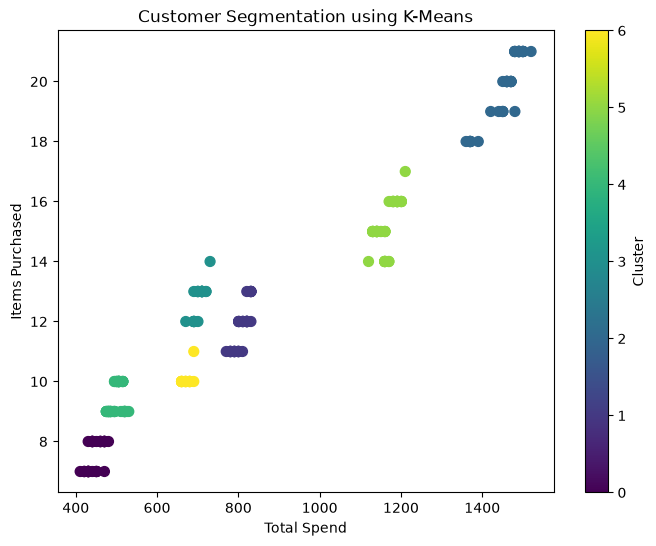

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Total Spend"],
    df["Items Purchased"],
    c=df["Cluster"],
    cmap="viridis",
    s=50
)

plt.xlabel("Total Spend")
plt.ylabel("Items Purchased")
plt.title("Customer Segmentation using K-Means")
plt.colorbar(label="Cluster")
plt.show()

In [9]:
cluster_profile = df.groupby("Cluster")[features].mean().round(2)

cluster_profile

,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
Cluster,,,,,
0,36.71,446.89,7.57,3.19,22.76
1,34.12,805.49,11.68,4.17,15.27
2,29.12,1459.77,20.00,4.81,11.17
3,26.79,703.69,12.76,4.02,53.18
4,42.02,499.88,9.41,3.46,40.47
5,30.71,1165.04,15.27,4.54,24.59
6,32.00,671.55,10.04,3.80,34.62


In [8]:
cluster_counts = df["Cluster"].value_counts().sort_index()

print(cluster_counts)

Cluster
0    58
1    59
2    58
3    34
4    58
5    59
6    24
Name: count, dtype: int64


In [7]:
optimal_k = 7

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means model trained successfully!")
print("Number of clusters:", df["Cluster"].nunique())

K-Means model trained successfully!
Number of clusters: 7


K=2: 0.482
K=3: 0.494
K=4: 0.563
K=5: 0.589
K=6: 0.657
K=7: 0.714
K=8: 0.685
K=9: 0.663
K=10: 0.627


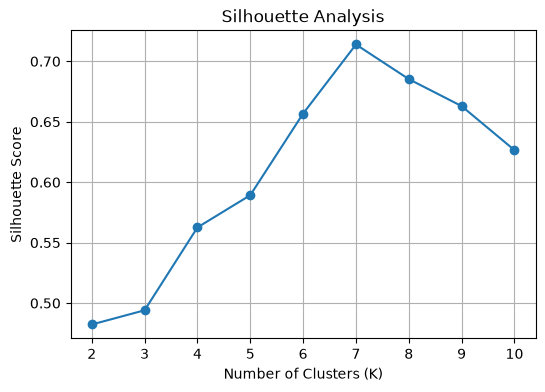

In [5]:
silhouette_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

for k, score in zip(range(2,11), silhouette_scores):
    print(f"K={k}: {score:.3f}")

plt.figure(figsize=(6,4))
plt.plot(range(2,11), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.grid(True)
plt.show()

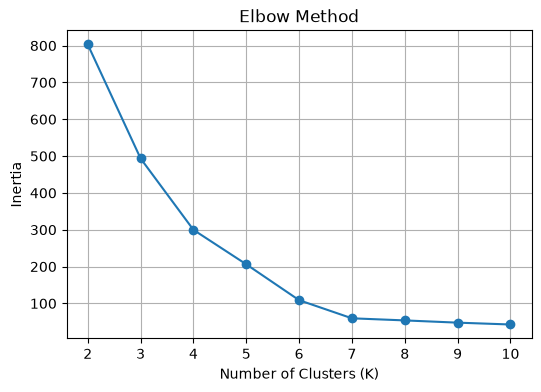

In [4]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2,11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (350, 5)


In [2]:
features = [
    "Age",
    "Total Spend",
    "Items Purchased",
    "Average Rating",
    "Days Since Last Purchase"
]

X = df[features].copy()

X.head()

,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
0,29,1120.20,14,4.6,25
1,34,780.50,11,4.1,18
2,43,510.75,9,3.4,42
3,30,1480.30,19,4.7,12
4,27,720.40,13,4.0,55


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("../data/cleaned_customer_behavior.csv")

df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied
